In [2]:
import pandas as pd

# Load CSV file
df = pd.read_csv("Dataset  (1).csv")

# Show first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
print(df.columns)
print(df.info())

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             95

In [5]:
df['Cuisines'] = df['Cuisines'].fillna("Unknown")
df['City'] = df['City'].fillna("Unknown")

# Level 1 

# Task 1 Top Cusines

In [6]:
cuisine_counts = df['Cuisines'].value_counts().head(3)
print(cuisine_counts)

cuisine_percent = (cuisine_counts / len(df)) * 100
print(cuisine_percent)

Cuisines
North Indian             936
North Indian, Chinese    511
Chinese                  354
Name: count, dtype: int64
Cuisines
North Indian             9.800021
North Indian, Chinese    5.350225
Chinese                  3.706418
Name: count, dtype: float64


# Task 2 City Analysis

In [13]:
# City with most restaurants
print(df['City'].value_counts().idxmax())

# Average rating per city
avg_rating = df.groupby('City')['Aggregate rating'].mean()
print(avg_rating)

# Highest rated city
print(avg_rating.idxmax())

New Delhi
City
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
Allahabad          3.395000
                     ...   
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
��stanbul          4.292857
Name: Aggregate rating, Length: 141, dtype: float64
Inner City


# Task 3: Price Range Distribution

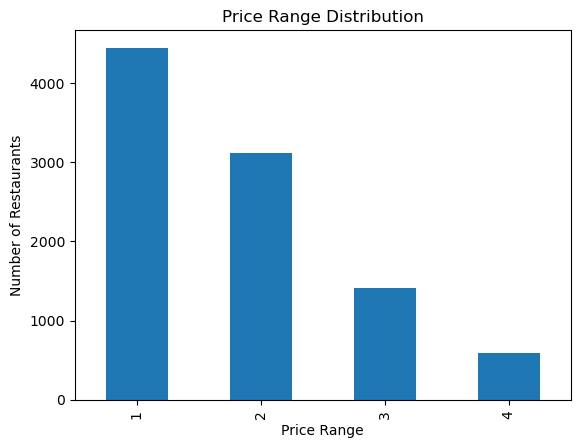

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64


In [15]:
import matplotlib.pyplot as plt

# Bar chart
df['Price range'].value_counts().plot(kind='bar')
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

# Percentage
price_percent = (df['Price range'].value_counts() / len(df)) * 100
print(price_percent)

# Task 4: Online Delivery

In [16]:
delivery_percent = df['Has Online delivery'].value_counts(normalize=True) * 100
print(delivery_percent)

delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(delivery_rating)

Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


# Level 2

# Task 1: Restaurant Ratings Analysis

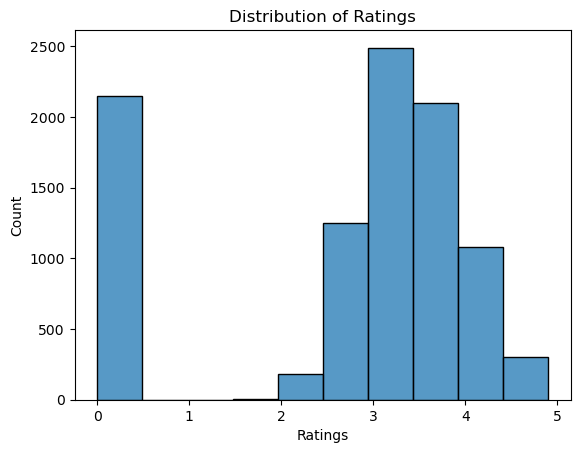

Most common rating: 0.0
Average votes: 156.909747670401


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of ratings
sns.histplot(df['Aggregate rating'], bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

# Most common rating
print("Most common rating:", df['Aggregate rating'].mode()[0])

# Average votes
print("Average votes:", df['Votes'].mean())

# Task 2: Cuisine Combination

In [18]:
# Top cuisine combinations
top_combinations = df['Cuisines'].value_counts().head(10)
print(top_combinations)

# Average rating per cuisine
cuisine_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
print(cuisine_rating.head(10))

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64
Cuisines
Continental, Indian             4.9
BBQ, Breakfast, Southern        4.9
Italian, Deli                   4.9
American, Caribbean, Seafood    4.9
Burger, Bar Food, Steak         4.9
American, Burger, Grill         4.9
Italian, Bakery, Continental    4.9
European, Asian, Indian         4.9
European, Contemporary          4.9
American, Coffee and Tea        4.9
Name: Aggregate rating, dtype: float64


# Task 3: Geographic Analysis

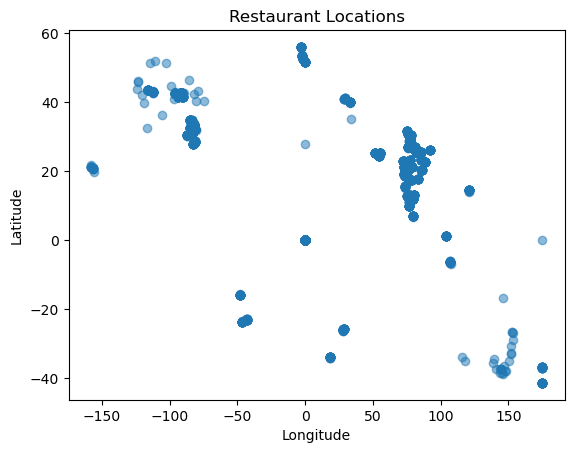

In [19]:
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.5)
plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Task 4: Restaurant Chains

In [20]:
# Find chains
chains = df['Restaurant Name'].value_counts()

# Show chains (more than 1 occurrence)
chains = chains[chains > 1].head(10)
print(chains)

# Ratings of top chains
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False)
print(chain_ratings.head(10))

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64
Restaurant Name
Restaurant Mosaic @ The Orient    4.9
Ministry of Crab                  4.9
Miann                             4.9
Shorts Burger and Shine           4.9
Milse                             4.9
Yellow Dog Eats                   4.9
Duck & Waffle                     4.9
Gaga Manjero                      4.9
Mirchi And Mime                   4.9
McGuire's Irish Pub & Brewery     4.9
Name: Aggregate rating, dtype: float64


# LEVEL 3

# Task 1: Restaurant Reviews Analysis

In [23]:
import matplotlib.pyplot as plt

# Check if review column exists
if 'Reviews' in df.columns:
    
    # Create review length column
    df['Review Length'] = df['Reviews'].astype(str).apply(len)
    
    # Average review length
    print("Average Review Length:", df['Review Length'].mean())
    
    # Plot relationship
    plt.scatter(df['Review Length'], df['Aggregate rating'], alpha=0.5)
    plt.title("Review Length vs Rating")
    plt.xlabel("Review Length")
    plt.ylabel("Rating")
    plt.show()

else:
    print("❌ No 'Reviews' column found in dataset → Skipping Task 1")

❌ No 'Reviews' column found in dataset → Skipping Task 1


# Task 2: Votes Analysis

Highest votes: 10934
Lowest votes: 0


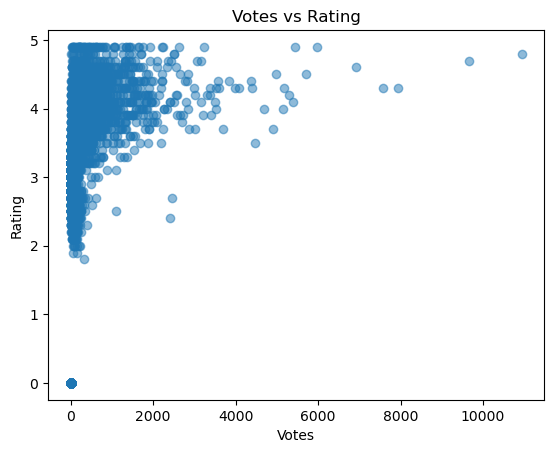

In [24]:
import matplotlib.pyplot as plt

# Highest votes
print("Highest votes:", df['Votes'].max())

# Lowest votes
print("Lowest votes:", df['Votes'].min())

# Scatter plot
plt.scatter(df['Votes'], df['Aggregate rating'], alpha=0.5)
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

# Task 3: Price Range vs Services

In [25]:
# Online delivery vs price
delivery_price = pd.crosstab(df['Price range'], df['Has Online delivery'])
print(delivery_price)

# Table booking vs price
booking_price = pd.crosstab(df['Price range'], df['Has Table booking'])
print(booking_price)

Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53
Has Table booking    No  Yes
Price range                 
1                  4443    1
2                  2874  239
3                   764  644
4                   312  274
